# 911 Calls Capstone Project

For this capstone project we will be analyzing some 911 call data. The data contains the following fields:

* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)

Just go along with this notebook and try to complete the instructions or answer the questions in bold using your Python and Data Science skills!

## Data and Setup

**Import numpy and pandas**

In [1]:
import numpy as np
import pandas as pd

**Import visualization libraries and set %matplotlib inline.**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

**Read in the csv file as a dataframe called df**

In [4]:
df=pd.read_csv("911.csv")

In [5]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


**Assess the dataset structure, data types, and missing values.**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


**Preview the dataset to understand the available attributes.**

In [7]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


**Identify the zip codes with the highest emergency call volumes.**

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

**Determine the townships generating the highest number of emergency calls.**

In [9]:
df['zip'].value_counts().head(5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

**Take a look at the 'title' column, how many unique title codes are there?**

In [10]:
len(df["title"].value_counts())

110

## Creating new features

**In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.** 

**For example, if the title column value is EMS: BACK PAINS/INJURY , the Reason column value would be EMS.**

In [12]:
df['Reasons/Departments']= df["title"].apply(lambda x:x.split(':')[0])

**Identify the dominant emergency service category.**

In [15]:
df['Reasons/Departments'].value_counts().idxmax()

'EMS'

**Visualize the distribution of emergency calls across service categories.**

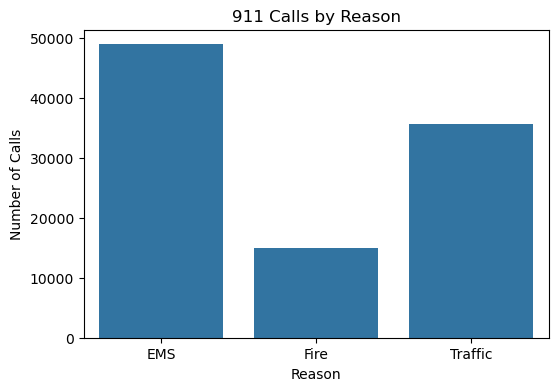

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Reasons/Departments', data=df)
plt.title('911 Calls by Reason')
plt.xlabel('Reason')
plt.ylabel('Number of Calls')
plt.show()

**data type of the objects in the timeStamp column**

In [24]:
df['timeStamp'].dtype

dtype('<M8[ns]')

**Prepare timestamp data for time-based analysis.**

In [23]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

**Extract key time-based features (Hour, Month, and Day of Week) from the timestamp to enable temporal analysis and identify patterns in emergency call activity.**

In [26]:
df['Hour']=df['timeStamp'].apply(lambda x:x.hour)
df['Month']=df['timeStamp'].apply(lambda x:x.month)
df['Day of Week']=df['timeStamp'].apply(lambda x:x.dayofweek)

In [29]:
df[['timeStamp', 'Hour', 'Month', 'Day of Week']]

,timeStamp,Hour,Month,Day of Week
0,2015-12-10 17:40:00,17,12,Thu
1,2015-12-10 17:40:00,17,12,Thu
2,2015-12-10 17:40:00,17,12,Thu
3,2015-12-10 17:40:01,17,12,Thu
4,2015-12-10 17:40:01,17,12,Thu
...,...,...,...,...
99487,2016-08-24 11:06:00,11,8,Wed
99488,2016-08-24 11:07:02,11,8,Wed
99489,2016-08-24 11:12:00,11,8,Wed
99490,2016-08-24 11:17:01,11,8,Wed


**Convert the numerical day-of-week values into their corresponding weekday names to improve readability and interpretation in the analysis and visualizations.**

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [28]:
dmap = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['Day of Week'] = df['Day of Week'].map(dmap)

**Analyze the distribution of emergency calls across the days of the week, segmented by emergency service category (EMS, Fire, and Traffic).**

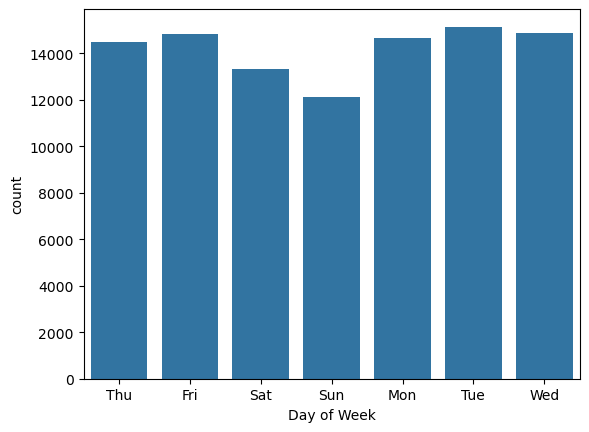

In [30]:
sns.countplot(x='Day of Week', data=df)
plt.show()

**Analyze the monthly distribution of emergency calls, segmented by emergency service category (EMS, Fire, and Traffic).**

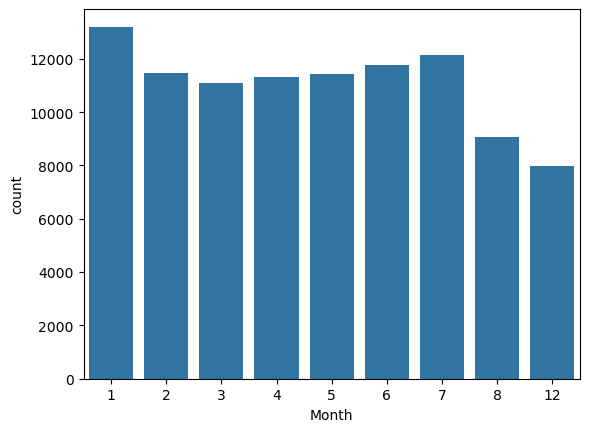

In [31]:
sns.countplot(data=df,x='Month')
plt.show()

**Investigate monthly emergency call trends by aggregating call volumes by month. Address missing month values and prepare the data for time-based trend analysis using Pandas.**

In [32]:
month_group = df.groupby('Month')['lat'].count()

In [33]:
month_group

Month
1     13205
2     11467
3     11101
4     11326
5     11423
6     11786
7     12137
8      9078
12     7969
Name: lat, dtype: int64

**Visualize monthly emergency call volumes to identify changes in demand patterns and understand variations in emergency service requirements over time.**

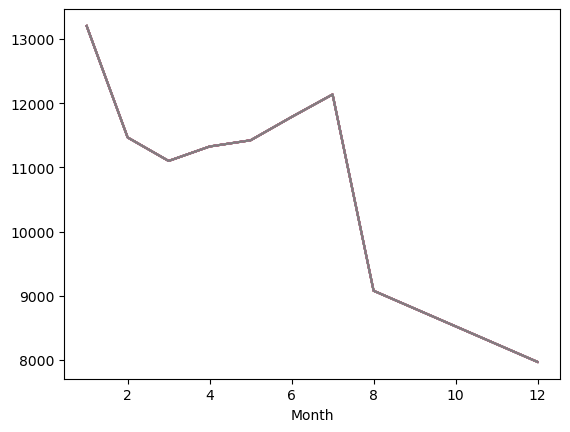

In [39]:

month_group.plot()
plt.show()

**Apply trend analysis to monthly emergency call volumes by fitting a linear regression model to identify overall growth or decline patterns over time.**

In [42]:
month_group = month_group.reset_index().rename({'lat':'count'},axis=1)

In [43]:
month_group

,Month,count
0,1,13205
1,2,11467
2,3,11101
3,4,11326
4,5,11423
5,6,11786
6,7,12137
7,8,9078
8,12,7969


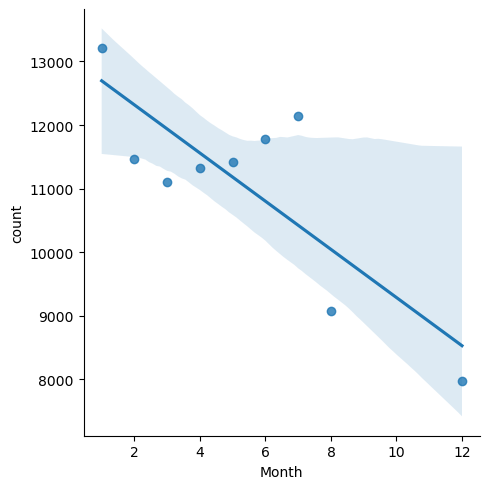

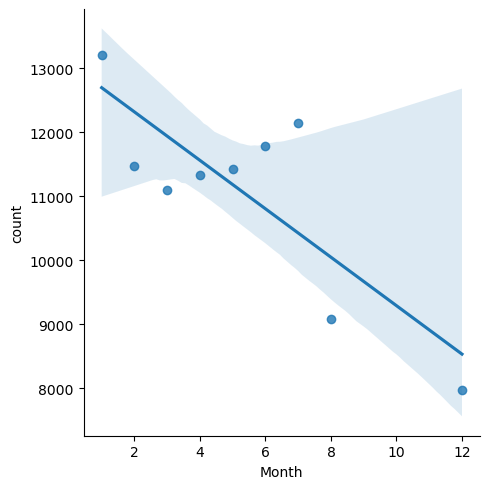

In [59]:
sns.lmplot(data=month_group,x='Month',y='count')
plt.show()

**Extract the date component from the timestamp to enable daily-level emergency call trend analysis.** 

In [46]:
df['Date'] = df.timeStamp.apply(lambda x:x.date())

**Aggregate emergency calls at a daily level and visualize the trend over time to identify fluctuations, peak periods, and changes in emergency service demand.*

In [47]:
date_group = df.groupby('Date')['Date'].count()

In [48]:
date_group.name='count'

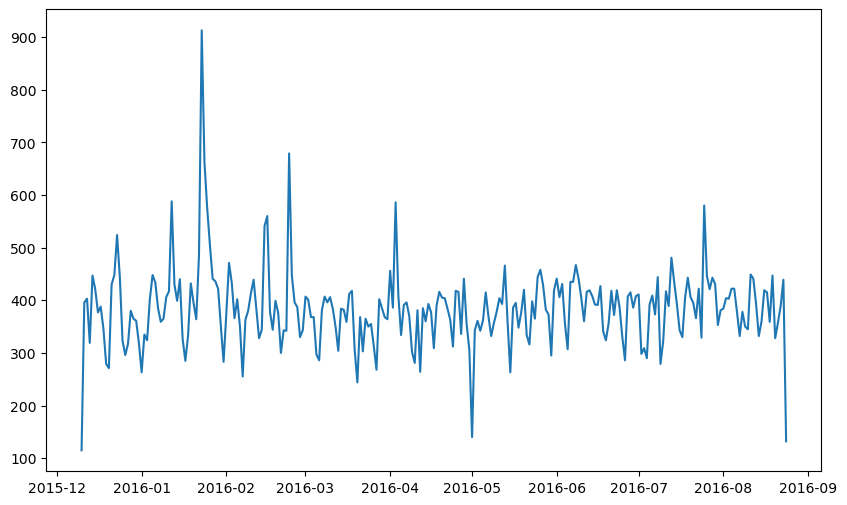

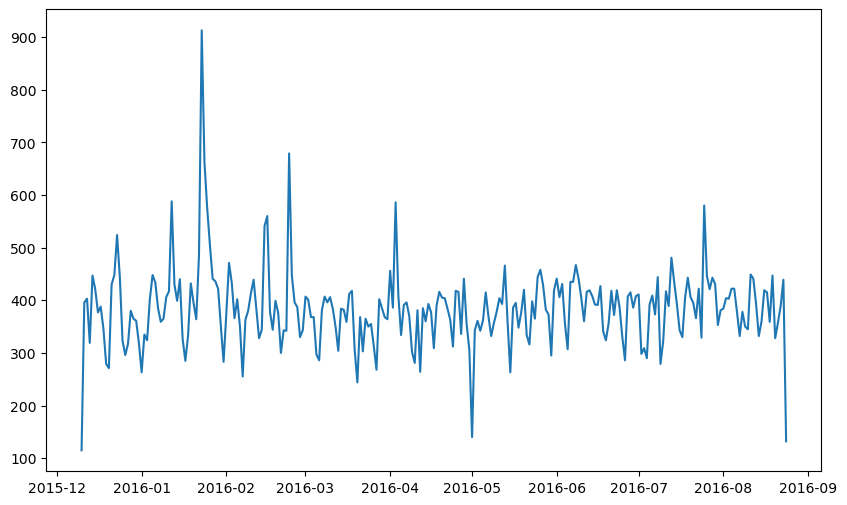

In [50]:
plt.figure(figsize=(10,6))
plt.plot(date_group)
plt.show()

**Compare daily emergency call trends across different service categories (EMS, Fire, and Traffic) to understand category-specific demand patterns over time.**

In [53]:
reason_date_group = df.groupby(['Reasons/Departments','Date'])['Date'].count()

In [54]:
reason_date_group.name = 'count'

In [55]:
reason_date_group = reason_date_group.reset_index()

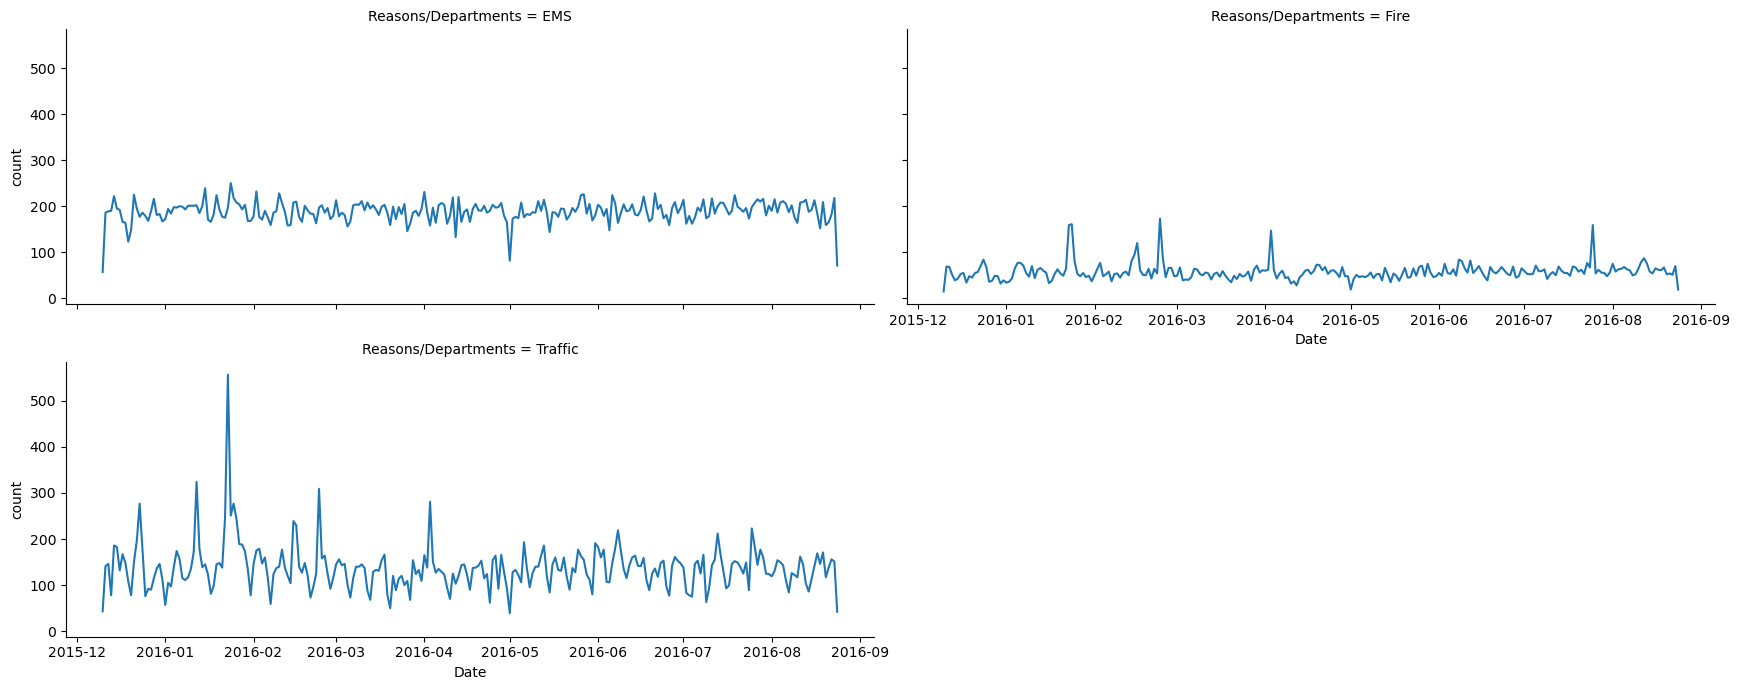

In [57]:
sns.relplot(kind='line',col='Reasons/Departments',x='Date',y='count',col_wrap=2,data=reason_date_group,aspect=2.5,height=3.5)
plt.show(BaseException)

**Restructure emergency call data by day of week and hour to identify peak demand periods and prepare the dataset for heatmap visualization.**

In [69]:
dayHour=df.groupby(['Day of Week','Hour']).count()['lat']
dayHour=dayHour.unstack()


**Visualize emergency call frequency by day of week and hour to identify high-demand time periods and support operational planning.**

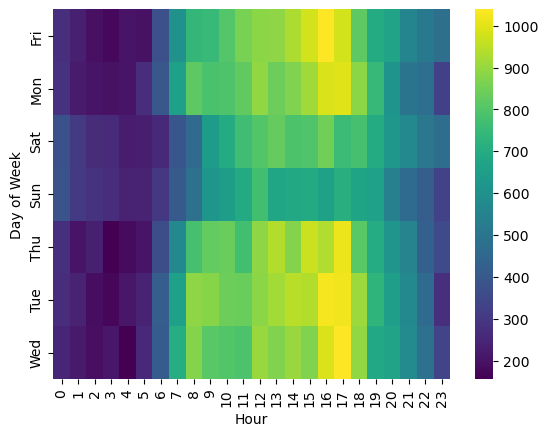

In [70]:
sns.heatmap(dayHour,cmap='viridis')
plt.show()

**Apply clustering analysis to hourly emergency call patterns to identify similarities between days and time periods.**

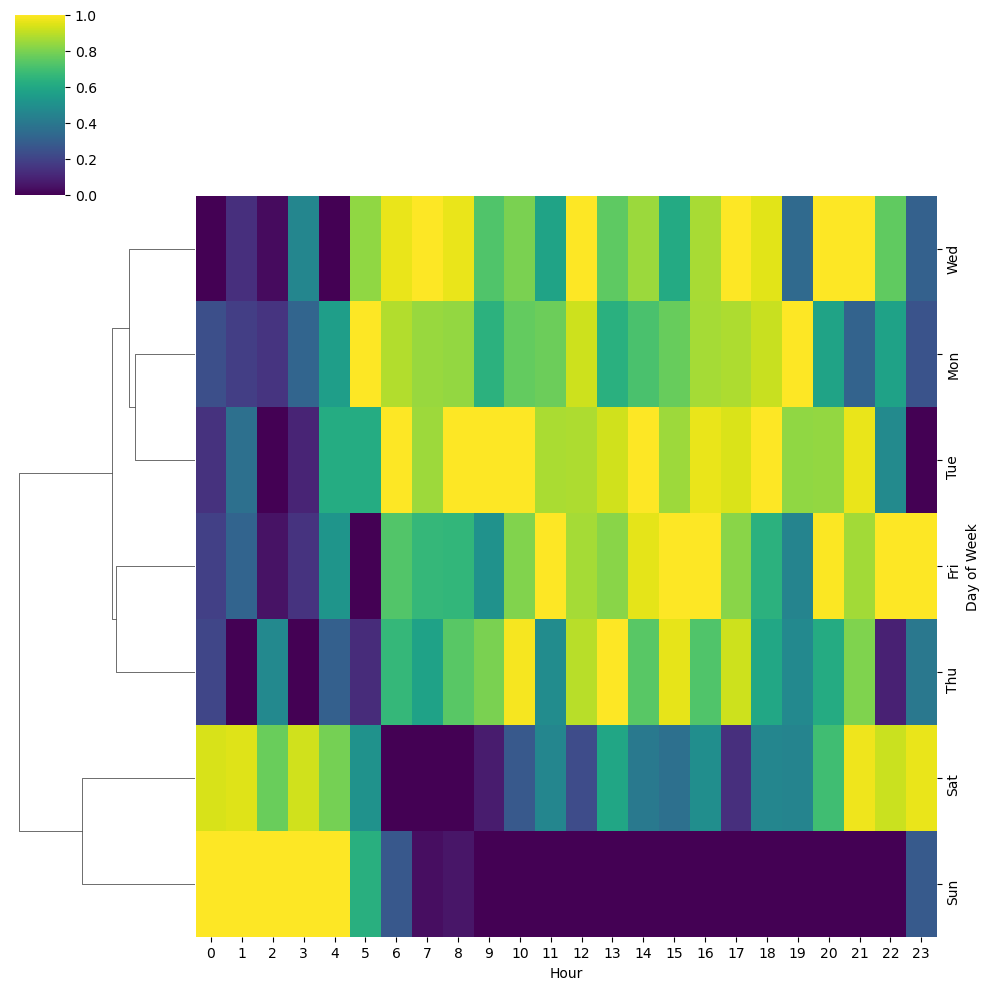

In [72]:
sns.clustermap(dayHour, cmap='viridis', standard_scale=1, col_cluster=False)
plt.show()


**Analyze emergency call patterns across different months and weekdays to identify seasonal trends and recurring demand patterns for resource planning.**

In [73]:
dayMonth = df.groupby(['Day of Week','Month']).count()['lat']
dayMonth = dayMonth.unstack()


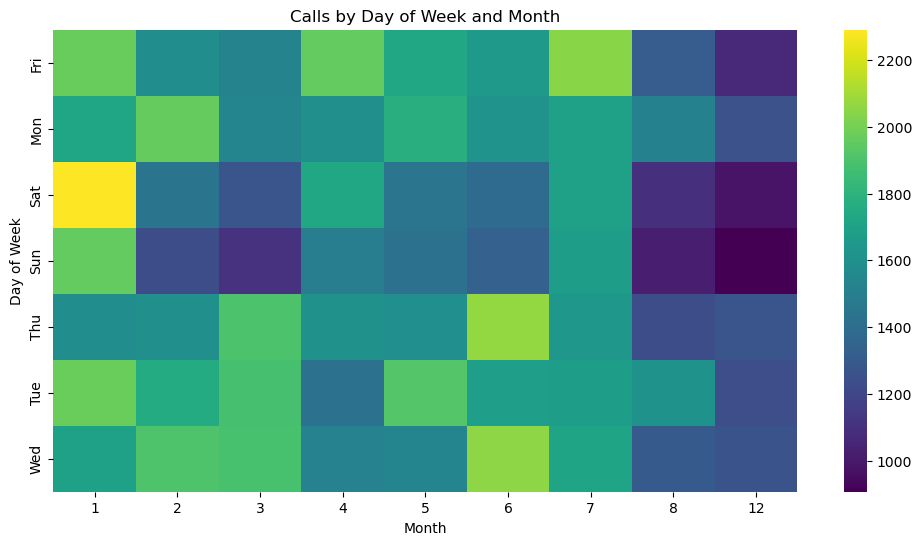

In [74]:
plt.figure(figsize=(12,6))
sns.heatmap(dayMonth, cmap='viridis')
plt.title("Calls by Day of Week and Month")
plt.show()

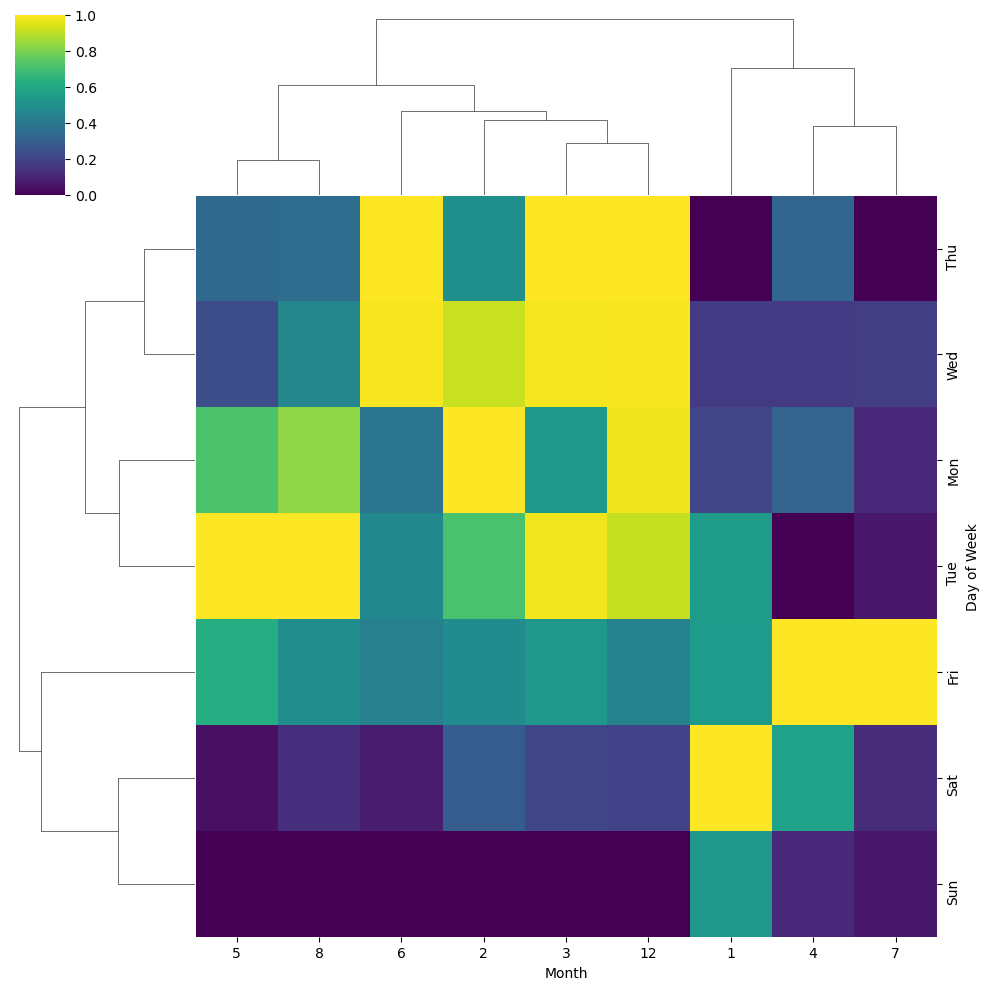

In [75]:
sns.clustermap(dayMonth, cmap='viridis', standard_scale=1)
plt.show()